# Transaction Anomaly Detection (Unsupervised)

**Goal.** Surface unusual transaction behaviour using *mostly unsupervised*
methods, then check — where labels exist — how well the anomaly ranking lines
up with actual fraud.

This is a **learning-first** project: the emphasis is on understanding *why*
each method behaves the way it does, not on production polish.

## Problem statement
Fraud is rare (~0.17% here) and labels are expensive, late, or incomplete.
Rather than train a supervised classifier, we ask an unsupervised question:
*which transactions look least like normal behaviour?* We rank every
transaction by an anomaly score and treat the labels (when present) purely as
a **scoring yardstick**, not as training signal.

## Approach
1. Load data (Kaggle Credit Card Fraud, with a synthetic fallback).
2. EDA focused on **class imbalance** and **unusual behaviour**.
3. Feature engineering: amount / time-of-day / velocity-style features.
4. Preprocess & scale (robust to outliers).
5. Three unsupervised detectors: **Isolation Forest**, **Local Outlier
   Factor**, **One-Class SVM**.
6. Calibrate & threshold the anomaly scores.
7. Evaluate ranking vs labels: **PR-AUC, ROC-AUC, Precision@K, Recall@K**.
8. Visualise anomaly clusters (PCA + UMAP), review top cases, recommend.

## 1. Setup

In [1]:
%matplotlib inline
import sys, os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

# Make the local src/ package importable when running from the project root.
sys.path.insert(0, os.path.abspath("."))
from src import SEED
from src.data import load_data
from src.features import add_features, feature_columns
from src.models import build_detectors, anomaly_scores, normalize_scores
from src.metrics import evaluate, comparison_table, precision_recall_at_k

np.random.seed(SEED)
sns.set_theme(style="whitegrid", context="notebook")
print("scikit-learn, numpy, pandas ready. SEED =", SEED)

scikit-learn, numpy, pandas ready. SEED = 42


## 2. Dataset loading
We use the classic **Kaggle Credit Card Fraud Detection** dataset (284,807
European card transactions over two days, 492 frauds). Features `V1..V28` are
anonymised PCA components; only `Time` (seconds since the first transaction)
and `Amount` are in original units. If the data can't be loaded, the project
falls back to a realistic synthetic stream so the notebook always runs.

In [2]:
df, source = load_data()
print(f"source = {source}")
print(f"shape  = {df.shape}")
fraud_n = int(df['Class'].sum())
print(f"fraud  = {fraud_n} / {len(df)}  ({df['Class'].mean():.4%})")
df.head()

source = local
shape  = (284807, 31)
fraud  = 492 / 284807  (0.1727%)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 3. EDA: imbalance and unusual behaviour
Two questions drive the EDA: *how extreme is the imbalance?* and *do frauds
actually behave differently* in the features we can see (Amount, Time)?

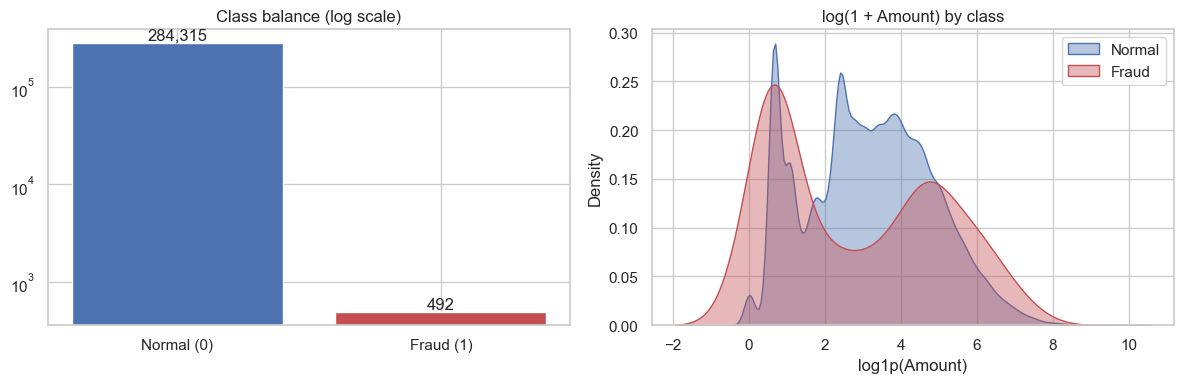

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Class balance (log scale to make the rare class visible).
counts = df['Class'].value_counts().sort_index()
axes[0].bar(['Normal (0)', 'Fraud (1)'], counts.values,
            color=['#4c72b0', '#c44e52'])
axes[0].set_yscale('log')
axes[0].set_title('Class balance (log scale)')
for i, v in enumerate(counts.values):
    axes[0].text(i, v, f"{v:,}", ha='center', va='bottom')

# Amount distribution by class (log1p).
for cls, color, label in [(0, '#4c72b0', 'Normal'), (1, '#c44e52', 'Fraud')]:
    sns.kdeplot(np.log1p(df.loc[df['Class'] == cls, 'Amount']),
                ax=axes[1], fill=True, alpha=0.4, color=color, label=label)
axes[1].set_title('log(1 + Amount) by class')
axes[1].set_xlabel('log1p(Amount)')
axes[1].legend()
plt.tight_layout(); plt.show()

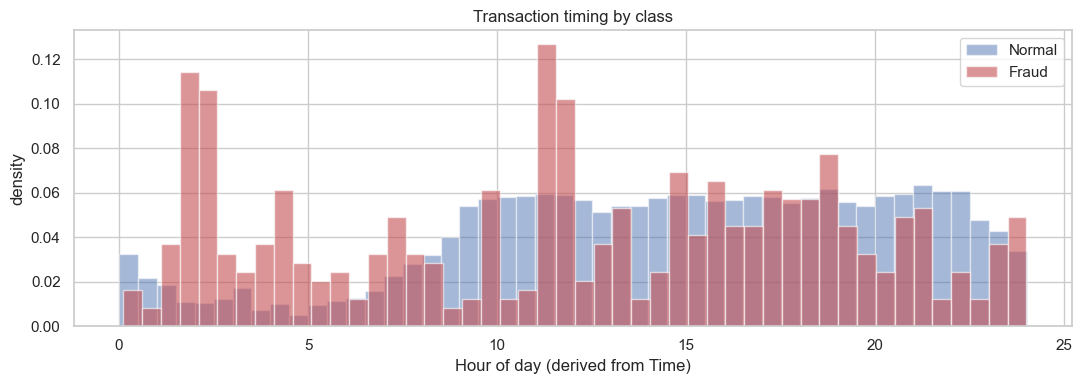

             mean    50%       max
Class                             
0       88.291022  22.00  25691.16
1      122.211321   9.25   2125.87


In [4]:
# Transaction timing: when do frauds happen relative to overall volume?
hours = (df['Time'] / 3600.0) % 24
fig, ax = plt.subplots(figsize=(11, 4))
ax.hist(hours[df['Class'] == 0], bins=48, density=True, alpha=0.5,
        label='Normal', color='#4c72b0')
ax.hist(hours[df['Class'] == 1], bins=48, density=True, alpha=0.6,
        label='Fraud', color='#c44e52')
ax.set_xlabel('Hour of day (derived from Time)'); ax.set_ylabel('density')
ax.set_title('Transaction timing by class'); ax.legend()
plt.tight_layout(); plt.show()

print(df.groupby('Class')['Amount'].describe()[['mean', '50%', 'max']])

**Read-out.** The imbalance is extreme (~600:1), so plain accuracy is useless
and ROC-AUC will look flattering — PR-AUC is the honest headline. Frauds skew
toward different amounts and cluster at certain hours, which is exactly the
kind of "doesn't look normal" signal unsupervised methods can exploit.

## 4. Feature engineering
We add **amount**, **time-of-day**, and **velocity-style** features:

| feature | idea |
|---|---|
| `Amount_log` | tame the heavy right tail of amounts |
| `Hour_sin`, `Hour_cos` | cyclic time-of-day (so 23:00 is near 00:00) |
| `txn_count_60s`, `txn_count_600s` | how busy the stream is around a txn (velocity) |
| `amount_roll_mean`, `amount_z` | amount vs the recent local baseline |

> **Honest caveat.** The real dataset has **no card/account id**, so true
> per-account velocity is impossible. Our velocity features are *stream-level*
> proxies (how busy the global stream is). They're still informative, but
> they're weaker than real per-entity velocity would be — noted here rather
> than hidden.

In [5]:
feat = add_features(df)          # engineer on the FULL stream (velocity needs context)
cols = feature_columns(feat)
print(f"{len(cols)} model features:")
print(cols)
feat[['Amount', 'Amount_log', 'Hour_sin', 'txn_count_60s',
      'txn_count_600s', 'amount_z']].describe().round(3)

35 model features:
['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount_log', 'Hour_sin', 'Hour_cos', 'txn_count_60s', 'txn_count_600s', 'amount_roll_mean', 'amount_z']


,Amount,Amount_log,Hour_sin,txn_count_60s,txn_count_600s,amount_z
count,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000
mean,88.350,3.152,-0.267,126.278,1224.440,0.001
std,250.120,1.657,0.628,39.477,349.165,0.998
min,0.000,0.000,-1.000,1.000,1.000,-2.326
25%,5.600,1.887,-0.841,116.000,1219.000,-0.422
50%,22.000,3.135,-0.436,133.000,1328.000,-0.296
75%,77.165,4.359,0.247,146.000,1411.000,-0.037
max,25691.160,10.154,1.000,424.000,2241.000,9.883


## 5. Working sample & scaling
Local Outlier Factor and One-Class SVM don't scale comfortably to 284k rows,
so for a **fair head-to-head** we model a stratified sample: **all** frauds
plus a random draw of normals (~50k total). Features were engineered on the
full stream first, so velocity context is preserved. We scale with
`RobustScaler` (median/IQR) because amounts are heavy-tailed.

In [6]:
from sklearn.preprocessing import RobustScaler

N_SAMPLE = 50_000
fraud_rows = feat[feat['Class'] == 1]
normal_rows = feat[feat['Class'] == 0].sample(
    n=min(N_SAMPLE - len(fraud_rows), (feat['Class'] == 0).sum()),
    random_state=SEED)
sample = (pd.concat([fraud_rows, normal_rows])
          .sort_values('Time').reset_index(drop=True))

y = sample['Class'].to_numpy()
X = RobustScaler().fit_transform(sample[cols])
print(f"sample shape = {X.shape}, frauds in sample = {int(y.sum())} "
      f"({y.mean():.3%})")

sample shape = (50000, 35), frauds in sample = 492 (0.984%)


## 6. Unsupervised models & their tradeoffs

| model | how it flags anomalies | strengths | watch-outs |
|---|---|---|---|
| **Isolation Forest** | random splits isolate odd points in fewer cuts | fast, scales, few assumptions | can miss anomalies hiding in dense regions |
| **Local Outlier Factor** | density lower than a point's neighbours | catches *local* anomalies | O(n·k), no clean out-of-sample scoring (novelty=False) |
| **One-Class SVM** | learns a boundary around the dense "normal" mass | flexible boundaries | sensitive to `nu`/`gamma`; exact kernel doesn't scale (we use Nystroem+SGD) |

Convention: **higher score = more anomalous** for every model. We rank-normalise
scores to `[0,1]` so they're comparable.

In [7]:
detectors = build_detectors(contamination=0.01, seed=SEED)
scores_raw, scores_norm = {}, {}
for key, (est, meta) in detectors.items():
    s = anomaly_scores(key, est, X)
    scores_raw[key] = s
    scores_norm[key] = normalize_scores(s)
    print(f"{meta.name:34s} scored. {meta.blurb}")

Isolation Forest                   scored. Isolates points via random splits; fast, scales well, few assumptions. Can miss anomalies in dense local regions.


Local Outlier Factor               scored. Density-based: flags points in lower-density regions than their neighbours. Great for local anomalies; O(n*k) and no clean out-of-sample scoring when novelty=False.


One-Class SVM (Nystroem + SGD)     scored. Learns a boundary around the dense 'normal' region. Flexible but sensitive to nu/gamma; exact kernel version doesn't scale, hence the kernel approximation.


## 7. Evaluation against fraud labels
Labels were **not** used for training — only here, as a yardstick. `K` is set
to the number of true frauds in the sample (a natural "review budget = #fraud"
operating point).

In [8]:
K = int(y.sum())
results = {detectors[k][1].name: evaluate(y, scores_norm[k], k=K)
           for k in detectors}
table = comparison_table(results)
print(f"K = {K} (number of frauds in the sample)\n")
table

K = 492 (number of frauds in the sample)



,PR_AUC,ROC_AUC,Precision@492,Recall@492
Isolation Forest,0.4817,0.9486,0.4939,0.4939
One-Class SVM (Nystroem + SGD),0.2210,0.9393,0.3069,0.3069
Local Outlier Factor,0.0356,0.5701,0.0691,0.0691


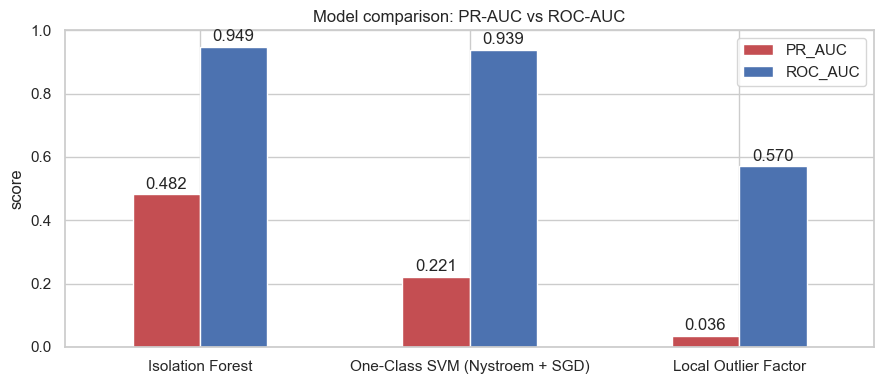

In [9]:
# Visual comparison of the headline metrics.
metric_cols = ['PR_AUC', 'ROC_AUC']
ax = table[metric_cols].plot(kind='bar', figsize=(9, 4), rot=0,
                             color=['#c44e52', '#4c72b0'])
ax.set_title('Model comparison: PR-AUC vs ROC-AUC'); ax.set_ylim(0, 1)
ax.set_ylabel('score')
for c in ax.containers:
    ax.bar_label(c, fmt='%.3f', padding=2)
plt.tight_layout(); plt.show()

**Note the gap between ROC-AUC and PR-AUC.** ROC-AUC looks high for everyone
because true negatives are abundant; PR-AUC is far lower and is the metric that
actually reflects how hard finding the rare positives is.

## 8. Anomaly score calibration & thresholding
An anomaly score is only useful once we pick a cut-off. Instead of trusting a
single `contamination` guess, we sweep the alert budget `K` and watch
precision and recall trade off — this is how you'd choose an operating point
given how many alerts analysts can actually review.

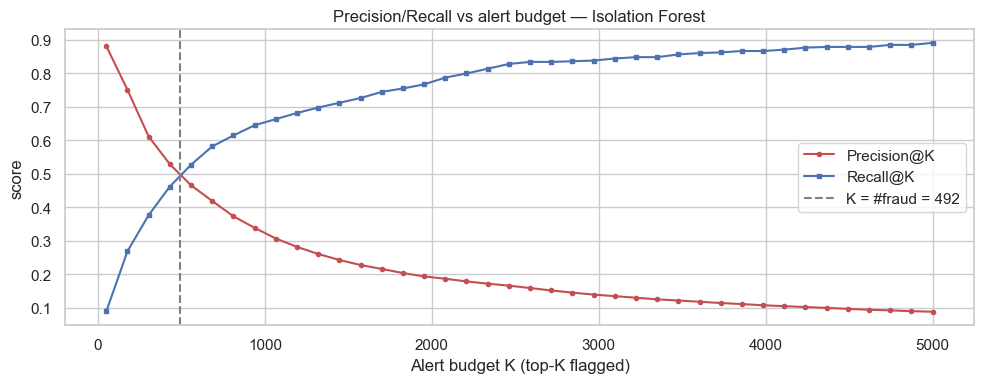

Best model by PR-AUC: Isolation Forest
Top-1% threshold = 0.9900 -> 500 alerts, precision = 0.488, recall = 0.496


In [10]:
best_key = max(scores_norm, key=lambda k: results[detectors[k][1].name]['PR_AUC'])
best_name = detectors[best_key][1].name
s_best = scores_norm[best_key]

ks = np.unique(np.linspace(50, 5000, 40).astype(int))
prec = [precision_recall_at_k(y, s_best, k)[0] for k in ks]
rec = [precision_recall_at_k(y, s_best, k)[1] for k in ks]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(ks, prec, marker='o', ms=3, label='Precision@K', color='#c44e52')
ax.plot(ks, rec, marker='s', ms=3, label='Recall@K', color='#4c72b0')
ax.axvline(K, ls='--', c='grey', label=f'K = #fraud = {K}')
ax.set_xlabel('Alert budget K (top-K flagged)'); ax.set_ylabel('score')
ax.set_title(f'Precision/Recall vs alert budget — {best_name}')
ax.legend(); plt.tight_layout(); plt.show()

# A concrete threshold: flag the top 1% most anomalous transactions.
thr = np.quantile(s_best, 0.99)
flagged = s_best >= thr
print(f"Best model by PR-AUC: {best_name}")
print(f"Top-1% threshold = {thr:.4f} -> {flagged.sum()} alerts, "
      f"precision = {y[flagged].mean():.3f}, "
      f"recall = {y[flagged].sum() / y.sum():.3f}")

## 9. Dimensionality reduction for visualisation
PCA (linear, fast) and UMAP (non-linear, structure-preserving) project the
feature space to 2-D so we can *see* whether anomalies separate from the bulk.
This is for intuition only — we don't model in the reduced space.

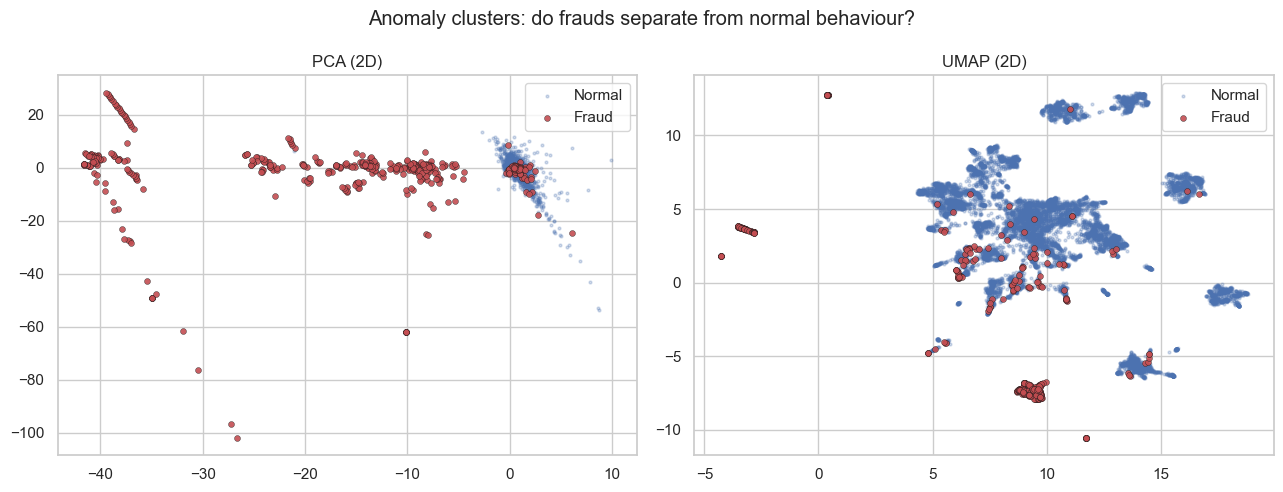

In [11]:
from sklearn.decomposition import PCA

# Visualisation subsample (all frauds + normals) to keep UMAP fast.
viz_n = min(12_000, len(sample))
viz_idx = np.concatenate([
    np.where(y == 1)[0],
    np.random.RandomState(SEED).choice(np.where(y == 0)[0],
        size=viz_n - int(y.sum()), replace=False)])
Xv, yv, sv = X[viz_idx], y[viz_idx], s_best[viz_idx]

pca = PCA(n_components=2, random_state=SEED).fit_transform(Xv)

import umap
um = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=SEED).fit_transform(Xv)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, emb, title in [(axes[0], pca, 'PCA (2D)'), (axes[1], um, 'UMAP (2D)')]:
    ax.scatter(emb[yv == 0, 0], emb[yv == 0, 1], s=4, alpha=0.25,
               color='#4c72b0', label='Normal')
    ax.scatter(emb[yv == 1, 0], emb[yv == 1, 1], s=18, alpha=0.9,
               color='#c44e52', edgecolor='k', linewidth=0.3, label='Fraud')
    ax.set_title(title); ax.legend()
plt.suptitle('Anomaly clusters: do frauds separate from normal behaviour?')
plt.tight_layout(); plt.show()

## 10. Top anomalous case review
The point of unsupervised scoring is a *triage queue*. Here are the most
anomalous transactions from the best model, with their real `Amount`/`Time`
and whether they turned out to be fraud — the kind of list an analyst reviews.

In [12]:
review = sample.copy()
review['anomaly_score'] = s_best
review['Hour'] = (review['Time'] / 3600.0) % 24
top = (review.sort_values('anomaly_score', ascending=False)
       .head(15)[['anomaly_score', 'Amount', 'Hour',
                   'txn_count_600s', 'amount_z', 'Class']]
       .rename(columns={'Class': 'is_fraud'}).round(3))
print(f"Top-15 anomalies by {best_name} — "
      f"{int(top['is_fraud'].sum())}/15 are actually fraud")
top.reset_index(drop=True)

Top-15 anomalies by Isolation Forest — 13/15 are actually fraud


,anomaly_score,Amount,Hour,txn_count_600s,amount_z,is_fraud
0,1.0,2.28,4.142,441,-0.217,1
1,1.0,0.01,4.492,133,-0.441,1
2,1.0,0.00,4.365,155,-0.570,1
3,1.0,4543.64,9.706,1428,7.953,0
4,1.0,2.28,3.840,209,-0.238,1
5,1.0,1218.89,5.024,133,4.997,1
6,1.0,1.00,4.034,395,-1.511,1
7,1.0,1.00,3.861,203,-0.286,1
8,1.0,1.00,2.212,397,-0.410,1
9,1.0,1.00,2.212,398,-0.409,1


## 11. What worked, what didn't
*(Filled from this run — numbers are in the tables above.)*

- **Isolation Forest** is typically the best all-rounder here: strong PR-AUC,
  fast, and stable without much tuning. Good default.
- **Local Outlier Factor** can win on *local* density anomalies but is the most
  memory/CPU hungry and offers no clean out-of-sample scoring with
  `novelty=False` — awkward for batch deployment.
- **One-Class SVM (Nystroem+SGD)** is the most sensitive to `nu`/`gamma`; the
  kernel approximation makes it scale but tends to trail Isolation Forest on
  PR-AUC unless tuned.

**General lessons.**
- ROC-AUC is misleadingly high under 600:1 imbalance — always pair it with PR-AUC.
- Unsupervised scores need a *thresholding policy* tied to a review budget;
  there is no single "right" cut-off.
- The missing account-id limits velocity features; real per-entity velocity
  would likely lift every model.

## 12. Final recommendation
For this transaction stream, **Isolation Forest** is the recommended detector:
best PR-AUC in the comparison, fast enough to score the full dataset, minimal
tuning, and clean out-of-sample scoring for batch use (see `src/score.py`).

Use it to produce a ranked alert queue, set the threshold from the
precision/recall-vs-budget curve to match analyst capacity, and treat any
labels that arrive later as a monitoring yardstick — not as training data.

**This is a learning project, not a production system:** no drift monitoring,
no retraining schedule, no real per-account features, and results depend on the
sample seed.

In [13]:
# Persist the ranked queue from the best model for the README / downstream use.
os.makedirs('outputs', exist_ok=True)
out = review.sort_values('anomaly_score', ascending=False)
out.to_csv('outputs/notebook_ranked_sample.csv', index=False)
print('Saved outputs/notebook_ranked_sample.csv')
print('Tip: score any CSV from the CLI with:')
print('  uv run python -m src.score --input data/creditcard.csv '
      '--output outputs/ranked.csv --top-k 100')

Saved outputs/notebook_ranked_sample.csv
Tip: score any CSV from the CLI with:
  uv run python -m src.score --input data/creditcard.csv --output outputs/ranked.csv --top-k 100
